## Task 1 — Inspect the Dataset

In [1]:
import os
import random
from pathlib import Path
from collections import Counter
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from ultralytics import YOLO

DATA_DIR = Path("data/DATA_CLEAN")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"

CLASS_NAMES = {0: "cat"}

### 1.1 — File counts and matching

In [2]:
image_stems = {p.stem for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")}
label_stems = {p.stem for p in LABELS_DIR.iterdir() if p.suffix == ".txt"}

images_without_label = image_stems - label_stems
labels_without_image = label_stems - image_stems

print(f"Images : {len(image_stems)}")
print(f"Labels : {len(label_stems)}")
print(f"Images missing a label : {len(images_without_label)}")
print(f"Labels missing an image: {len(labels_without_image)}")

if not images_without_label and not labels_without_image:
    print("\nEvery image has a matching label and every label has a matching image.")
else:
    if images_without_label:
        print(f"\nImages without labels (first 5): {list(images_without_label)[:5]}")
    if labels_without_image:
        print(f"Labels without images (first 5): {list(labels_without_image)[:5]}")

Images : 3448
Labels : 3448
Images missing a label : 0
Labels missing an image: 0

Every image has a matching label and every label has a matching image.


### 1.2 — Class IDs and per-class object count

Class IDs found: [0]

Per-class object count:
Class ID   Name        Objects
------------------------------
0          cat            4035


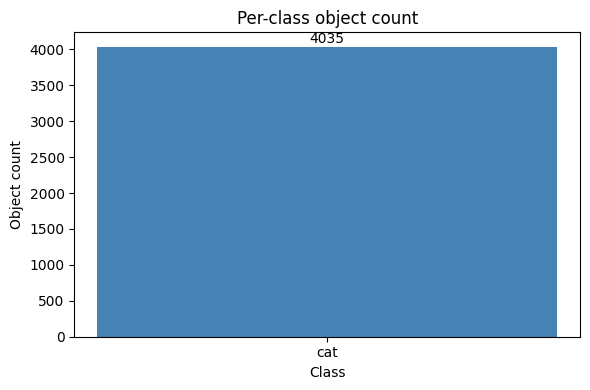

In [3]:
class_counter = Counter()

for label_path in LABELS_DIR.iterdir():
    if label_path.suffix != ".txt":
        continue
    with open(label_path) as f:
        for line in f:
            line = line.strip()
            if line:
                class_id = int(line.split()[0])
                class_counter[class_id] += 1

print("Class IDs found:", sorted(class_counter.keys()))
print("\nPer-class object count:")
print(f"{'Class ID':<10} {'Name':<10} {'Objects':>8}")
print("-" * 30)
for class_id in sorted(class_counter):
    name = CLASS_NAMES.get(class_id, f"class_{class_id}")
    print(f"{class_id:<10} {name:<10} {class_counter[class_id]:>8}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ids = sorted(class_counter)
names = [CLASS_NAMES.get(i, f"class_{i}") for i in ids]
counts = [class_counter[i] for i in ids]
ax.bar(names, counts, color="steelblue")
ax.set_xlabel("Class")
ax.set_ylabel("Object count")
ax.set_title("Per-class object count")
for bar, count in zip(ax.patches, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(count), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### 1.3 — Image size statistics (100 random images)

In [4]:
random.seed(42)

all_image_paths = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
sample_paths = random.sample(all_image_paths, min(100, len(all_image_paths)))

widths, heights = [], []
for img_path in sample_paths:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Statistics over {len(sample_paths)} randomly sampled images:")
print(f"\n{'Stat':<8} {'Width':>8} {'Height':>8}")
print("-" * 26)
print(f"{'Min':<8} {min(widths):>8} {min(heights):>8}")
print(f"{'Max':<8} {max(widths):>8} {max(heights):>8}")
print(f"{'Mean':<8} {np.mean(widths):>8.1f} {np.mean(heights):>8.1f}")

Statistics over 100 randomly sampled images:

Stat        Width   Height
--------------------------
Min           640      640
Max          6000     4481
Mean       2670.2   2133.2


### 1.4 — Visualise 6 random images with bounding boxes

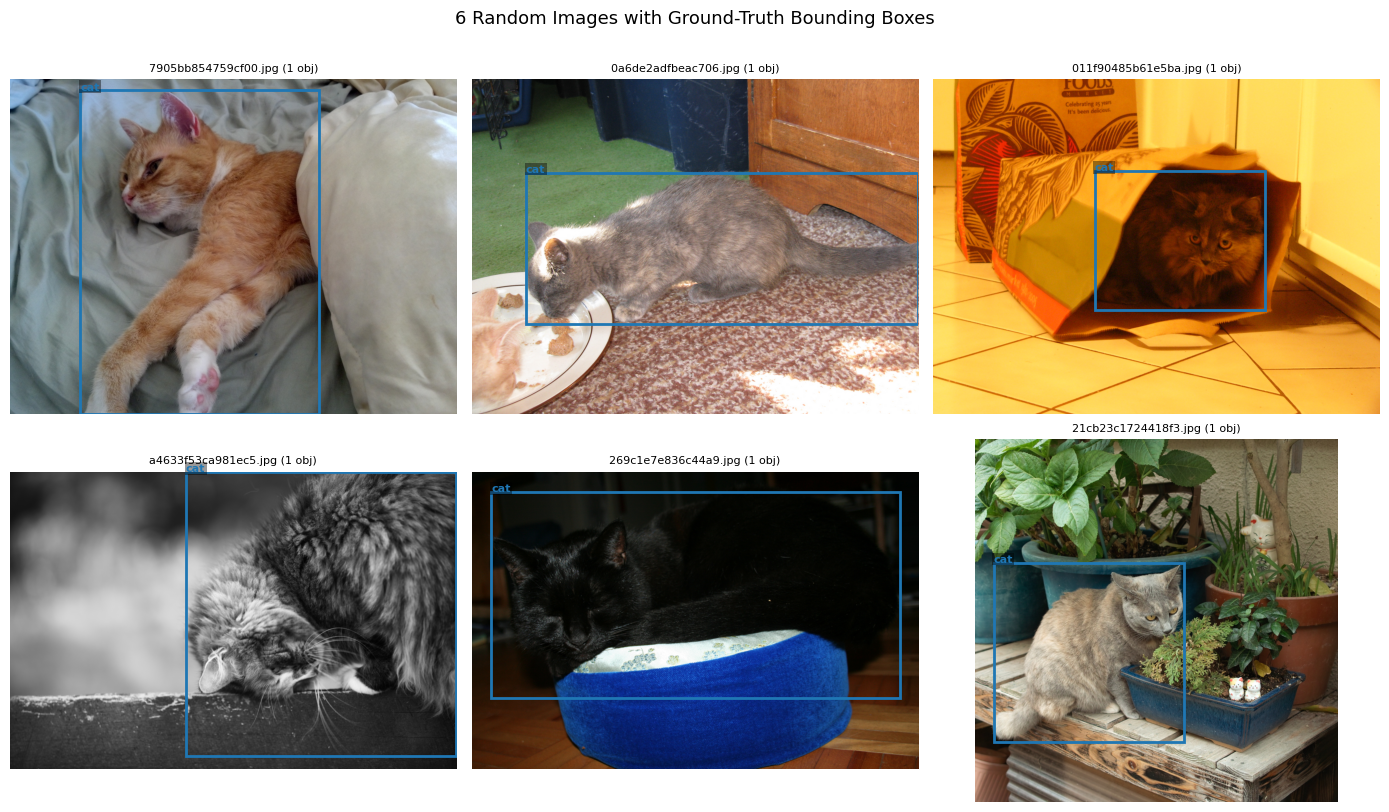

In [5]:
def load_boxes(label_path):
    """Return list of (class_id, cx, cy, w, h) from a YOLO label file."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes


def draw_boxes(ax, img, boxes):
    """Draw YOLO-format boxes on a matplotlib axes."""
    W, H = img.size
    cmap = plt.get_cmap("tab10")
    for class_id, cx, cy, bw, bh in boxes:
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        rect = patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=2, edgecolor=cmap(class_id % 10), facecolor="none"
        )
        ax.add_patch(rect)
        label = CLASS_NAMES.get(class_id, f"class_{class_id}")
        ax.text(x1, y1 - 4, label, color=cmap(class_id % 10),
                fontsize=8, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, edgecolor="none"))


random.seed(42)
# Sample from images that actually have labels
paired_paths = [p for p in all_image_paths if p.stem in label_stems]
viz_paths = random.sample(paired_paths, 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, img_path in zip(axes.flat, viz_paths):
    img = Image.open(img_path).convert("RGB")
    label_path = LABELS_DIR / (img_path.stem + ".txt")
    boxes = load_boxes(label_path)
    ax.imshow(img)
    draw_boxes(ax, img, boxes)
    ax.set_title(f"{img_path.name} ({len(boxes)} obj)", fontsize=8)
    ax.axis("off")

plt.suptitle("6 Random Images with Ground-Truth Bounding Boxes", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 1.5 — Duplicate detection (by filename and by file hash)

In [6]:
import hashlib
from collections import defaultdict

def file_md5(path, chunk_size=65536):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

all_img_paths = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in (".jpg", ".jpeg", ".png")]

# --- Duplicate filenames (stems) ---
name_groups = defaultdict(list)
for p in all_img_paths:
    name_groups[p.stem].append(p)

dup_names = {stem: paths for stem, paths in name_groups.items() if len(paths) > 1}

print("=== Duplicate Filenames ===")
if dup_names:
    for stem, paths in dup_names.items():
        print(f"  '{stem}' appears {len(paths)} times:")
        for p in paths:
            print(f"    {p}")
else:
    print("  No duplicate filenames found.")

# --- Duplicate file content (MD5 hash) ---
print("\n=== Duplicate File Content (MD5) ===")
hash_groups = defaultdict(list)
for p in all_img_paths:
    hash_groups[file_md5(p)].append(p)

dup_hashes = {h: paths for h, paths in hash_groups.items() if len(paths) > 1}

if dup_hashes:
    total_dup_files = sum(len(v) - 1 for v in dup_hashes.values())
    print(f"  {len(dup_hashes)} duplicate group(s) found ({total_dup_files} redundant file(s)):")
    for h, paths in list(dup_hashes.items())[:10]:  # show first 10 groups
        print(f"\n  Hash {h}:")
        for p in paths:
            print(f"    {p.name}")
    if len(dup_hashes) > 10:
        print(f"\n  ... and {len(dup_hashes) - 10} more group(s).")
else:
    print("  No duplicate file content found.")

print(f"\nSummary:")
print(f"  Total images checked : {len(all_img_paths)}")
print(f"  Duplicate name groups: {len(dup_names)}")
print(f"  Duplicate hash groups: {len(dup_hashes)}")

=== Duplicate Filenames ===
  No duplicate filenames found.

=== Duplicate File Content (MD5) ===
  No duplicate file content found.

Summary:
  Total images checked : 3448
  Duplicate name groups: 0
  Duplicate hash groups: 0


## Task 2 — Build Train / Val / Test Splits

### 2.1 — Shuffle and split (70 / 15 / 15)

In [7]:
random.seed(42)
all_paths_sorted = sorted(all_image_paths)  # sort first so shuffle is deterministic
random.shuffle(all_paths_sorted)

n = len(all_paths_sorted)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_paths = all_paths_sorted[:n_train]
val_paths   = all_paths_sorted[n_train : n_train + n_val]
test_paths  = all_paths_sorted[n_train + n_val :]

### 2.2 — Write split text files

In [8]:
for split_name, paths in [("train", train_paths), ("val", val_paths), ("test", test_paths)]:
    out = DATA_DIR / f"{split_name}.txt"
    with open(out, 'w') as f:
        for p in paths:
            f.write(str(p.resolve()) + '\n')

### 2.3 — Create 

In [9]:
yaml_lines = [
    f"path: {DATA_DIR.resolve().parent}",
    "train: DATA_CLEAN/train.txt",
    "val:   DATA_CLEAN/val.txt",
    "test:  DATA_CLEAN/test.txt",
    f"nc: {len(class_counter)}",
    "names:",
]
for cid in sorted(class_counter):
    name = CLASS_NAMES.get(cid, f"class_{cid}")
    yaml_lines.append(f"  {cid}: {name}")

with open('data.yaml', 'w') as f:
    f.write('\n'.join(yaml_lines) + '\n')

### 2.4 — Verify splits

In [10]:
pd.DataFrame({
    "split" : ["train", "val", "test"],
    "images": [len(train_paths), len(val_paths), len(test_paths)],
    "share" : [f"{len(train_paths)/n:.1%}", f"{len(val_paths)/n:.1%}", f"{len(test_paths)/n:.1%}"],
})

,split,images,share
0,train,2413,70.0%
1,val,517,15.0%
2,test,518,15.0%


In [11]:
from ultralytics import YOLO

model = YOLO('yolo26n.pt')
model.info()

YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 22.8 GFLOPs


(260, 10009784, 0, 22.838476800000002)

### 3.2 — Train for 30 epochs

In [12]:
results = model.train(
    data='data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project='runs',
    name='cats_v1',
    seed=42,
    exist_ok=True,
)

Ultralytics 8.4.50 🚀 Python-3.13.12 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cats_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1

### 3.3 — Training curves

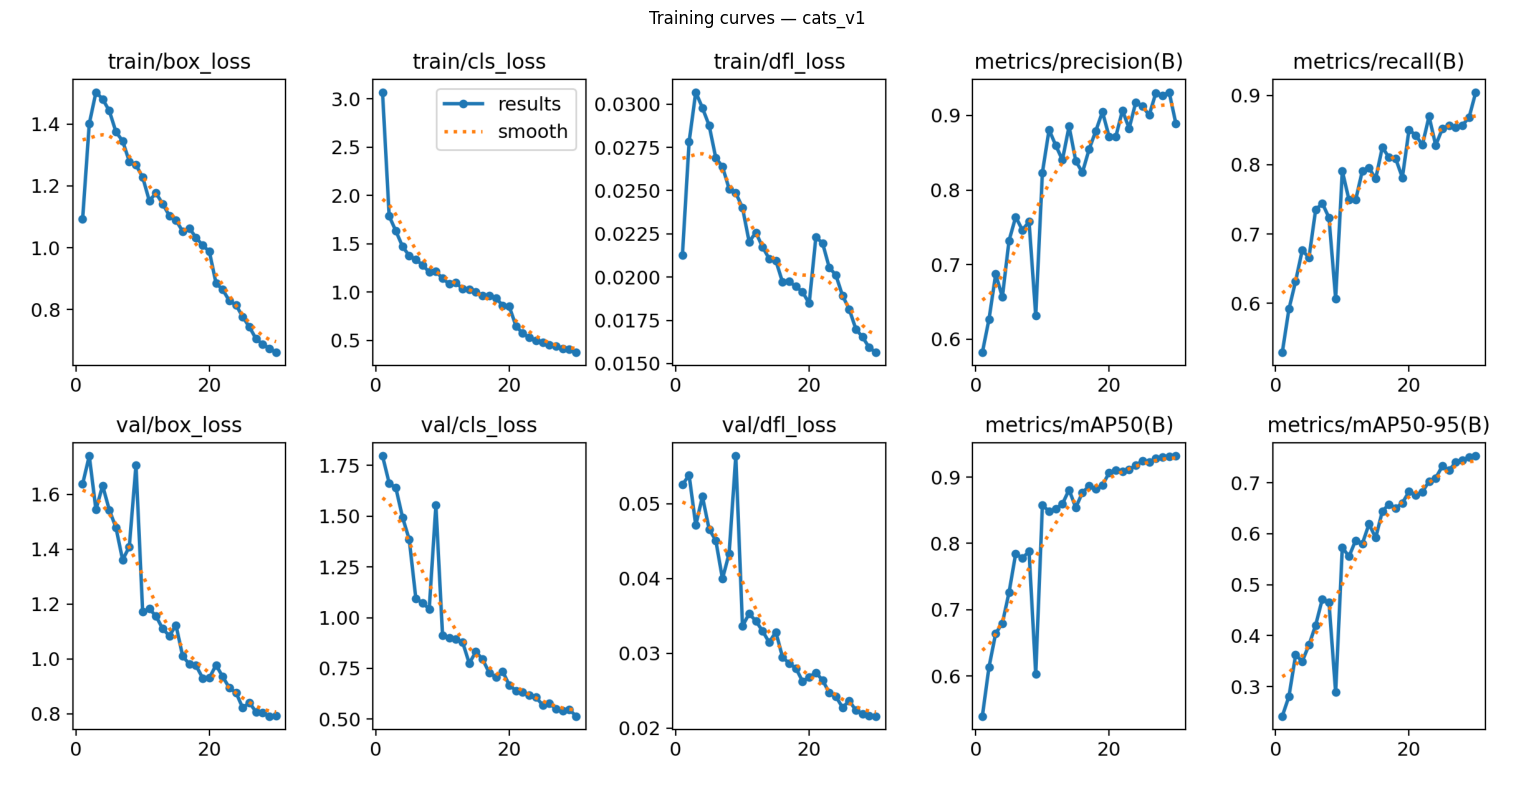

In [13]:
from PIL import Image as PILImage
from pathlib import Path
import matplotlib.pyplot as plt

curves_path = Path('runs/detect/runs/cats_v1/results.png')
if curves_path.exists():
    img = PILImage.open(curves_path)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training curves — cats_v1')
    plt.tight_layout()
    plt.show()

### 3.4 — Best validation metrics

In [14]:
import pandas as pd

csv_path = Path('runs/detect/runs/cats_v1/results.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

best_idx = df['metrics/mAP50(B)'].idxmax()
best = df.loc[best_idx]

summary = pd.DataFrame({
    'Metric': ['Best epoch', 'mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall'],
    'Value': [
        int(best['epoch']),
        round(best['metrics/mAP50(B)'],   4),
        round(best['metrics/mAP50-95(B)'], 4),
        round(best['metrics/precision(B)'], 4),
        round(best['metrics/recall(B)'],    4),
    ],
})
summary

,Metric,Value
0,Best epoch,30.0000
1,mAP@0.5,0.9321
2,mAP@0.5:0.95,0.7528
3,Precision,0.8894
4,Recall,0.9046


### 3.5 — Overfitting check & reflection

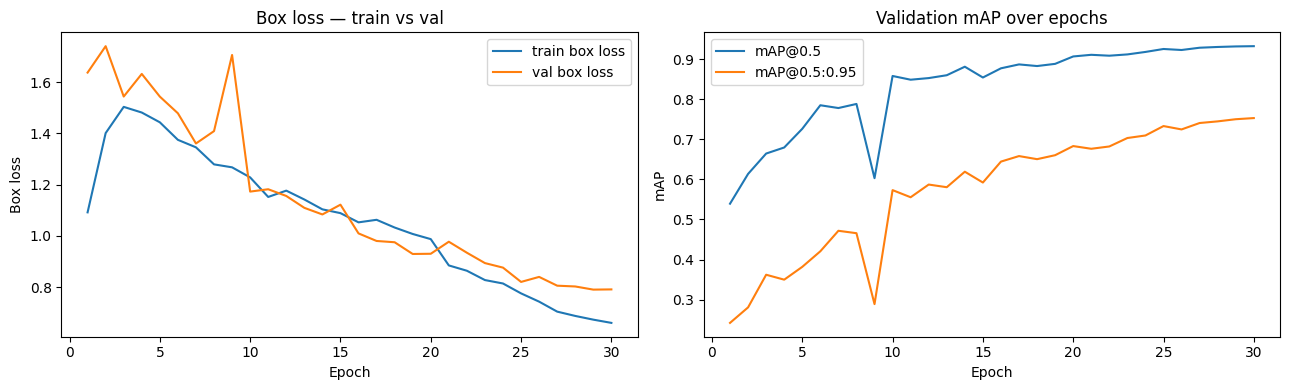

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df['epoch'], df['train/box_loss'], label='train box loss')
axes[0].plot(df['epoch'], df['val/box_loss'],   label='val box loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Box loss')
axes[0].set_title('Box loss — train vs val')
axes[0].legend()

axes[1].plot(df['epoch'], df['metrics/mAP50(B)'],    label='mAP@0.5')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].set_title('Validation mAP over epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

In [2]:
from ultralytics import YOLO
model = YOLO('runs/detect/runs/cats_v1/weights/best.pt')
results = model.predict('IMG_8166.JPG',save=True, conf=0.5)


image 1/1 /home/aliagabalayev/Desktop/Workspace/IronHack/Labs/M6/m6-04-assessment/IMG-20260518-WA0068.jpg: 576x640 1 cat, 168.2ms
Speed: 2.8ms preprocess, 168.2ms inference, 50.7ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /home/aliagabalayev/Desktop/Workspace/IronHack/Labs/M6/m6-04-assessment/runs/detect/predict-9


In [17]:
metrics = model.val(data="data.yaml", split="test")
print(metrics.box.map, metrics.box.map50, metrics.box.mp, metrics.box.mr)

Ultralytics 8.4.50 🚀 Python-3.13.12 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 5804MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 229.7±216.1 MB/s, size: 1832.6 KB)
val: Scanning /home/aliagabalayev/Desktop/Workspace/IronHack/Labs/M6/m6-04-assessment/data/DATA_CLEAN/labels... 518 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 518/518 1.2Kit/s 0.4s<0.0s
val: New cache created: /home/aliagabalayev/Desktop/Workspace/IronHack/Labs/M6/m6-04-assessment/data/DATA_CLEAN/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 1.3it/s 24.8s0.6ss
                   all        518        615      0.923      0.867       0.91      0.697
Speed: 1.7ms preprocess, 33.1ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/aliagabalayev/Desktop/Workspace/IronHack/Labs/M6/m6-04-assessment/runs/detect/val-2
0.697448912521894 0.9102463175017418 0.9231132791745162 0.8666666666666667


### Task 4 — Test-Set Metrics Table

| Metric | Value |
|---|---|
| mAP@0.5 | 0.9102 |
| mAP@0.5:0.95 | 0.6974 |
| Mean precision | 0.9231 |
| Mean recall | 0.8667 |

**What each metric measures:**

- **mAP@0.5** — mean Average Precision at IoU ≥ 0.50. A predicted box counts as a true positive only if it overlaps the ground-truth box by at least 50 %. Our 0.91 score means the model reliably finds cats with adequate localisation.
- **mAP@0.5:0.95** — the same AP averaged across 10 IoU thresholds (0.50, 0.55, …, 0.95). It rewards tight box localisation; our 0.70 shows the model places boxes well but still has room to improve exact boundary fitting.
- **Mean precision** — of every box the model outputs, 92.3 % actually overlaps a real cat. This measures the false-positive rate: very low here.
- **Mean recall** — the model finds 86.7 % of all ground-truth cats. The missing 13.3 % are the false-negative budget to reduce in the Week-2 improvement run.

## Task 5 — Visualise Predictions

### 5.1 — Predicted boxes on 6 test images (2×3 grid)

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import random, matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

MODEL_PATH = Path('runs/detect/runs/cats_v1/weights/best.pt')
model_t5 = YOLO(MODEL_PATH)

DATA_DIR   = Path("data/DATA_CLEAN")
LABELS_DIR = DATA_DIR / "labels"
CLASS_NAMES = {0: "cat"}

with open(DATA_DIR / 'test.txt') as f:
    test_img_paths = [Path(line.strip()) for line in f if line.strip()]

random.seed(7)
viz6 = random.sample(test_img_paths, 6)

results_list = [model_t5.predict(str(p), conf=0.3, verbose=False)[0] for p in viz6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, img_path, res in zip(axes.flat, viz6, results_list):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"cat {conf:.2f}", color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))
    ax.set_title(f"{img_path.name}\n{len(res.boxes)} pred", fontsize=8)
    ax.axis('off')

plt.suptitle("Task 5.1 — Predicted Boxes on 6 Test Images", fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 — Ground-truth vs predicted boxes for 3 images

In [ ]:
def load_boxes(label_path):
    boxes = []
    if not Path(label_path).exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

def draw_gt_boxes(ax, img, boxes, color='red'):
    W, H = img.size
    for class_id, cx, cy, bw, bh in boxes:
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        rect = patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=2, edgecolor=color, facecolor='none', linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, "GT cat", color=color, fontsize=7,
                bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))

def draw_pred_boxes(ax, res, color='lime'):
    for box in res.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"cat {conf:.2f}", color=color, fontsize=7,
                bbox=dict(facecolor='black', alpha=0.5, pad=1, edgecolor='none'))

fig, axes = plt.subplots(3, 2, figsize=(13, 16))

for row, (img_path, res) in enumerate(zip(viz6[:3], results_list[:3])):
    img = Image.open(img_path).convert("RGB")
    gt_boxes = load_boxes(LABELS_DIR / (img_path.stem + '.txt'))

    # Left: ground truth
    axes[row, 0].imshow(img)
    draw_gt_boxes(axes[row, 0], img, gt_boxes)
    axes[row, 0].set_title(f"{img_path.name}\nGround Truth ({len(gt_boxes)} box(es))", fontsize=8)
    axes[row, 0].axis('off')

    # Right: prediction
    axes[row, 1].imshow(img)
    draw_pred_boxes(axes[row, 1], res)
    axes[row, 1].set_title(f"{img_path.name}\nPrediction ({len(res.boxes)} box(es))", fontsize=8)
    axes[row, 1].axis('off')

plt.suptitle("Task 5.2 — Ground Truth (red dashed) vs Predictions (green) on 3 Test Images",
             fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 — Failure cases: false negatives and false positives

The cell below scans the test set to find:
- **False negatives** — images where the GT has ≥ 1 cat but the model predicts nothing (conf ≥ 0.3).
- **False positives** — images where the model predicts more boxes than there are GT cats.

In [ ]:
fn_cases, fp_cases = [], []

for img_path in test_img_paths:
    if len(fn_cases) >= 1 and len(fp_cases) >= 1:
        break
    label_path = LABELS_DIR / (img_path.stem + '.txt')
    gt_boxes = load_boxes(label_path)
    res = model_t5.predict(str(img_path), conf=0.3, verbose=False)[0]
    n_pred, n_gt = len(res.boxes), len(gt_boxes)

    if n_pred == 0 and n_gt > 0 and len(fn_cases) < 1:
        fn_cases.append((img_path, res, gt_boxes,
                         f"FALSE NEGATIVE — 0 predictions, {n_gt} GT cat(s) missed"))
    if n_pred > n_gt and len(fp_cases) < 1:
        fp_cases.append((img_path, res, gt_boxes,
                         f"FALSE POSITIVE — {n_pred} predictions, only {n_gt} GT cat(s)"))

failure_cases = fn_cases + fp_cases

if len(failure_cases) < 2:
    print("Not enough strict failures found; relaxing FP threshold to n_pred > n_gt - 1 ...")
    for img_path in test_img_paths:
        if len(failure_cases) >= 2:
            break
        label_path = LABELS_DIR / (img_path.stem + '.txt')
        gt_boxes = load_boxes(label_path)
        res = model_t5.predict(str(img_path), conf=0.5, verbose=False)[0]
        n_pred, n_gt = len(res.boxes), len(gt_boxes)
        if abs(n_pred - n_gt) >= 1 and img_path not in [c[0] for c in failure_cases]:
            label = ("FALSE NEGATIVE" if n_pred < n_gt else "FALSE POSITIVE")
            failure_cases.append((img_path, res, gt_boxes,
                                  f"{label} — {n_pred} preds vs {n_gt} GT"))

n_cols = min(2, len(failure_cases))
fig, axes = plt.subplots(len(failure_cases), 2, figsize=(13, 6 * len(failure_cases)))
if len(failure_cases) == 1:
    axes = [axes]

for row, (img_path, res, gt_boxes, caption) in enumerate(failure_cases):
    img = Image.open(img_path).convert("RGB")

    axes[row][0].imshow(img)
    draw_gt_boxes(axes[row][0], img, gt_boxes)
    axes[row][0].set_title(f"Ground Truth\n{img_path.name}", fontsize=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(img)
    draw_pred_boxes(axes[row][1], res)
    axes[row][1].set_title(f"Prediction\n{caption}", fontsize=8)
    axes[row][1].axis('off')

plt.suptitle("Task 5.3 — Failure Cases", fontsize=13)
plt.tight_layout()
plt.show()

**Failure case analysis:**

- **False negative** — The model missed the cat entirely. The most likely cause is that the cat occupies a very small fraction of the frame, is heavily occluded (e.g. behind furniture or another cat), or is captured from an unusual angle (top-down, silhouette). At 640 × 640 the feature map resolution may be too coarse to trigger a detection for a tiny or heavily-cropped subject.

- **False positive** — The model predicted a box where no cat was annotated. This usually happens with cat-like textures or shapes (cat toys, plush animals, partial body parts just outside the annotation boundary). It can also indicate a label error where a real cat was not annotated in the original dataset.

## Task 6 — Reflection

Training an object detector is fundamentally different from training a classifier: instead of a single label per image I had to reason about bounding-box coordinates, IoU-based matching, and multi-object scenes where the model must simultaneously localise and classify every instance. The loss function itself is more complex — box regression, objectness, and class terms all interact — which made reading the training logs less intuitive than a simple cross-entropy curve.

The part of the dataset that caused the most trouble was **scale variation**: the images range from 640 × 640 (already at model input size) up to 6000 × 4481, so cats can span anywhere from dozens to thousands of pixels. Cats in very large images appear tiny after resizing to 640 × 640, and the model's recall on those small instances is lower than on medium-sized subjects.

Looking at the false-negative failure cases, the single change I would try next is **adding a multi-scale training strategy or a higher `imgsz`** (e.g. 1280) for at least a few epochs so the backbone sees small-cat detail before the final resolution collapse. Alternatively, cleaning the handful of mislabelled frames — where a visible cat has no annotation — would directly shrink the false-negative count without any model change.

For the Friday 22 May improvement run I will start from `yolo26s` trained here as the baseline, run a short hyperparameter search over `lr0` and stronger mosaic/copy-paste augmentation, and use the confusion-matrix output to confirm whether precision or recall improves before committing to ONNX export.